In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import glob

TIME_CODER = xr.coders.CFDatetimeCoder(use_cftime=True)

# Where the CMIP6 data sits on the NERSC mirror, and which run we use.
MIRROR = "/global/cfs/cdirs/m3522/cmip6/CMIP6"
MODEL, MEMBER, GRID = "MPI-ESM1-2-HR", "r1i1p1f1", "gn"

# Our four cities. Longitudes are in the model's 0-360 convention
# (a west longitude like -112 is written as 360 - 112 = 248).
CITIES = {
    "Phoenix":   (33.4484, 247.926),
    "Tucson":    (32.2226, 249.025),
    "Charlotte": (35.2271, 279.157),
    "Miami":     (25.7617, 279.808),
}

WARM_MONTHS = [5, 6, 7, 8, 9]          # May - September

# Baseline = "today's climate": historical (1996-2014) spliced with
# ssp370 (2015-2026). Future = next 30 years, all ssp370.
BASELINE = (1996, 2026)
FUTURE   = (2027, 2057)

In [5]:
# Historical and ssp370 live under different institution folders
# (MPI-M vs DKRZ), so we gather both and stitch them into one series.

def files(var):
    hist = sorted(glob.glob(f"{MIRROR}/CMIP/MPI-M/{MODEL}/historical/{MEMBER}/day/{var}/{GRID}/*/*.nc"))
    ssp  = sorted(glob.glob(f"{MIRROR}/ScenarioMIP/DKRZ/{MODEL}/ssp370/{MEMBER}/day/{var}/{GRID}/*/*.nc"))
    return hist + ssp

def extract(var):
    # open_mfdataset lazily glues all the yearly files into one long record
    ds = xr.open_mfdataset(files(var), combine="by_coords", decode_times=TIME_CODER,
                       data_vars="minimal", coords="minimal", compat="override")

    # we only need 1996-2057
    da = ds[var].sel(time=slice("1996", "2057"))

    series = []
    for city, (lat, lon) in CITIES.items():
        pt = da.sel(lat=lat, lon=lon, method="nearest")
        print(f"{city:9s} -> nearest grid lat {float(pt.lat):6.2f}, lon {float(pt.lon):7.2f}")
        series.append(pt.drop_vars(["lat", "lon"]))
    stacked = xr.concat(series, dim=pd.Index(list(CITIES), name="city"))

    # convert Kelvin -> Celsius so thresholds come out in familiar units.
    return stacked.load() - 273.15

tasmax = extract("tasmax")
tasmin = extract("tasmin")
print("\nloaded dims:", dict(tasmax.sizes))

Phoenix   -> nearest grid lat  33.19, lon  247.50
Tucson    -> nearest grid lat  32.26, lon  249.38
Charlotte -> nearest grid lat  35.06, lon  279.38
Miami     -> nearest grid lat  25.71, lon  279.38
Phoenix   -> nearest grid lat  33.19, lon  247.50
Tucson    -> nearest grid lat  32.26, lon  249.38
Charlotte -> nearest grid lat  35.06, lon  279.38
Miami     -> nearest grid lat  25.71, lon  279.38

loaded dims: {'city': 4, 'time': 22646}


In [4]:
tv = tasmax.time.values
steps = np.array([(tv[i+1] - tv[i]).days for i in range(len(tv) - 1)])
print("day-steps present (want [1] only):", np.unique(steps))

yrs = np.array([t.year for t in tv])
print("years:", yrs.min(), "->", yrs.max(), "| distinct years:", len(np.unique(yrs)))

vc = pd.Series(yrs).value_counts().sort_index()
print("\ndays per year (first/last 3):")
print(vc.head(3)); print(vc.tail(3))
print("\nsplice check  2014:", int(vc.loc[2014]), " 2015:", int(vc.loc[2015]))

day-steps present (want [1] only): [1]
years: 1996 -> 2057 | distinct years: 62

days per year (first/last 3):
1996    366
1997    365
1998    365
Name: count, dtype: int64
2055    365
2056    366
2057    365
Name: count, dtype: int64

splice check  2014: 365  2015: 365


In [6]:
def warm(da):
    return da.sel(time=da.time.dt.month.isin(WARM_MONTHS))

base_tx = warm(tasmax.sel(time=slice(str(BASELINE[0]), str(BASELINE[1]))))
base_tn = warm(tasmin.sel(time=slice(str(BASELINE[0]), str(BASELINE[1]))))

TX95 = base_tx.quantile(0.95, dim="time").drop_vars("quantile")
TN95 = base_tn.quantile(0.95, dim="time").drop_vars("quantile")

print("Baseline warm-season 95th-percentile thresholds (degC):")
print(pd.DataFrame({"TX95": TX95.to_series().round(2),
                    "TN95": TN95.to_series().round(2)}))

Baseline warm-season 95th-percentile thresholds (degC):
            TX95   TN95
city                   
Phoenix    43.73  31.11
Tucson     40.73  27.47
Charlotte  31.90  23.66
Miami      34.89  28.61


In [7]:
# Land-fraction check. At ~100 km resolution a coastal city's nearest
# gridcell can be mostly ocean, which drags its daytime max down and
# its humidity up. sftlf is a fixed (fx) field: percent land per cell.

sftlf_files = glob.glob(f"{MIRROR}/CMIP/MPI-M/{MODEL}/historical/{MEMBER}/fx/sftlf/{GRID}/*/*.nc")
print("sftlf file found:", len(sftlf_files))

lsm = xr.open_dataset(sftlf_files[0])["sftlf"]        # percent land, 0-100
print("\nland fraction at each city's nearest gridcell:")
for city, (lat, lon) in CITIES.items():
    cell = lsm.sel(lat=lat, lon=lon, method="nearest")
    print(f"  {city:9s} {float(cell):5.1f}% land   (grid {float(cell.lat):6.2f}, {float(cell.lon):7.2f})")

sftlf file found: 1

land fraction at each city's nearest gridcell:
  Phoenix   100.0% land   (grid  33.19,  247.50)
  Tucson    100.0% land   (grid  32.26,  249.38)
  Charlotte 100.0% land   (grid  35.06,  279.38)
  Miami     100.0% land   (grid  25.71,  279.38)


In [8]:
# Definitions being counted, one warm season at a time:
#   hot day         = tasmax above TX95
#   hot night       = tasmin above TN95
#   heatwave        = 3+ hot days IN A ROW
#   hot-night event = 3+ hot nights in a row
# Counting each year's May-Sep block on its own means Sep 30 can never
# accidentally connect to the following May 1.

def count_runs(mask, min_len=3):
    """Walk a True/False series for one season and count the stretches
    of consecutive True's that are at least `min_len` long.
    Returns (number_of_events, total_days_in_those_events)."""
    n_events = n_days = run = 0
    for is_hot in mask:
        if is_hot:
            run += 1                    # extend the current hot streak
        else:
            if run >= min_len:         
                n_events += 1
                n_days   += run
            run = 0                     # reset for the next streak
    if run >= min_len:                  # catch a streak that runs to Sep 30
        n_events += 1
        n_days   += run
    return n_events, n_days

def metrics_by_year(tx_city, tn_city, tx95, tn95, y0, y1):
    """Tally all four metrics for one city, for every year in [y0, y1]."""
    rows = []
    for y in range(y0, y1 + 1):
        # this single year's warm season, compared to the FIXED cutoffs
        hot_day   = warm(tx_city.sel(time=str(y))).values > tx95
        hot_night = warm(tn_city.sel(time=str(y))).values > tn95

        hw_events, hw_days = count_runs(hot_day)      # 3+ day heatwaves
        hn_events, hn_days = count_runs(hot_night)    # 3+ night events

        rows.append(dict(
            year       = y,
            hot_days   = int(hot_day.sum()),          # total hot days that season
            hot_nights = int(hot_night.sum()),        # total hot nights
            hw_events  = hw_events,                   # number of heatwaves
            hw_days    = hw_days,                     # days spent in heatwaves
            hn_events  = hn_events,
            hn_days    = hn_days,
        ))
    return pd.DataFrame(rows)

# run it for every city, for both periods, and stack into one tidy table
records = []
for city in CITIES:
    tx_c, tn_c = tasmax.sel(city=city), tasmin.sel(city=city)
    tx95, tn95 = float(TX95.sel(city=city)), float(TN95.sel(city=city))
    for period, (y0, y1) in {"baseline": BASELINE, "future": FUTURE}.items():
        df_city = metrics_by_year(tx_c, tn_c, tx95, tn95, y0, y1)
        df_city["city"], df_city["period"] = city, period
        records.append(df_city)

metrics = pd.concat(records, ignore_index=True)
print("per-year table shape:", metrics.shape)
metrics.head()

per-year table shape: (248, 9)


,year,hot_days,hot_nights,hw_events,hw_days,hn_events,hn_days,city,period
0,1996,0,3,0,0,0,0,Phoenix,baseline
1,1997,3,4,1,3,0,0,Phoenix,baseline
2,1998,1,4,0,0,1,4,Phoenix,baseline
3,1999,1,3,0,0,0,0,Phoenix,baseline
4,2000,7,1,1,3,0,0,Phoenix,baseline


In [9]:
print(metrics.groupby(["city", "period"]).size())

city       period  
Charlotte  baseline    31
           future      31
Miami      baseline    31
           future      31
Phoenix    baseline    31
           future      31
Tucson     baseline    31
           future      31
dtype: int64


In [10]:
pd.set_option("display.max_rows", 250)
metrics 

,year,hot_days,hot_nights,hw_events,hw_days,hn_events,hn_days,city,period
0,1996,0,3,0,0,0,0,Phoenix,baseline
1,1997,3,4,1,3,0,0,Phoenix,baseline
2,1998,1,4,0,0,1,4,Phoenix,baseline
3,1999,1,3,0,0,0,0,Phoenix,baseline
4,2000,7,1,1,3,0,0,Phoenix,baseline
5,2001,8,2,1,3,0,0,Phoenix,baseline
6,2002,7,10,1,3,2,6,Phoenix,baseline
7,2003,4,12,0,0,0,0,Phoenix,baseline
8,2004,6,8,1,3,2,8,Phoenix,baseline
9,2005,3,3,1,3,0,0,Phoenix,baseline


In [11]:
# Average each metric across the years to compare "today" vs "future".
# The jump from baseline -> future is the main result of the study.

cols = ["hot_days", "hot_nights", "hw_events", "hw_days", "hn_events", "hn_days"]
summary = metrics.groupby(["city", "period"])[cols].mean().round(1)
print("Mean per warm season, baseline vs future:\n")
print(summary)

Mean per warm season, baseline vs future:

                    hot_days  hot_nights  hw_events  hw_days  hn_events  \
city      period                                                          
Charlotte baseline       7.7         7.7        1.1      4.4        0.8   
          future        34.2        37.3        4.5     27.4        4.2   
Miami     baseline       7.7         7.7        1.0      4.1        0.6   
          future        19.3        28.6        2.2     13.0        2.6   
Phoenix   baseline       7.7         7.7        1.3      5.3        0.9   
          future        17.1        18.0        2.7     12.8        2.4   
Tucson    baseline       7.7         7.7        1.4      5.8        0.8   
          future        15.8        17.3        2.6     13.3        2.4   

                    hn_days  
city      period             
Charlotte baseline      2.7  
          future       30.2  
Miami     baseline      2.9  
          future       22.5  
Phoenix   baseline      3.

In [ ]:
import os

REPO = "/pscratch/sd/s/sarya4/github/HeatWaveAnalysis"
DATA = f"{REPO}/data"
os.makedirs(DATA, exist_ok=True)

# 1) the full daily city series: historical(1996-2014) + ssp370(2015-2057),
# all 4 cities, every day. This is the input everything else derives from.
city_ds = xr.Dataset({"tasmax": tasmax, "tasmin": tasmin})
city_ds.attrs.update(
    model=MODEL, member=MEMBER, grid=GRID,
    experiments="historical 1996-2014 spliced with ssp370 2015-2057",
    units="degC", source="NERSC CMIP6 mirror /global/cfs/cdirs/m3522/cmip6",
    note="nearest gridcell per city; sftlf = 100% land for all four",
)
city_ds.to_netcdf(f"{DATA}/city_daily_tasmax_tasmin_1996_2057.nc")

# plain CSV too, so it opens anywhere without xarray
df = city_ds.to_dataframe().reset_index()
df["time"] = df["time"].astype(str)          # cftime -> "YYYY-MM-DD"
df.to_csv(f"{DATA}/city_daily_tasmax_tasmin_1996_2057.csv", index=False)

# 2) the fixed baseline thresholds
pd.DataFrame({"TX95": TX95.to_series().round(3),
              "TN95": TN95.to_series().round(3)}).to_csv(f"{DATA}/thresholds_baseline.csv")

# 3) per-year counts for every city and both periods
metrics.to_csv(f"{DATA}/metrics_by_year.csv", index=False)

# 4) the baseline-vs-future summary (the headline table)
cols = ["hot_days", "hot_nights", "hw_events", "hw_days", "hn_events", "hn_days"]
(metrics.groupby(["city", "period"])[cols].mean().round(2)
        .to_csv(f"{DATA}/summary_baseline_vs_future.csv"))

print("saved to", DATA)
for f in sorted(os.listdir(DATA)):
    print(f"  {f:50s} {os.path.getsize(os.path.join(DATA, f))/1e6:7.2f} MB")

saved fig_hot_days.png
saved fig_hot_nights.png
saved fig_heatwaves.png


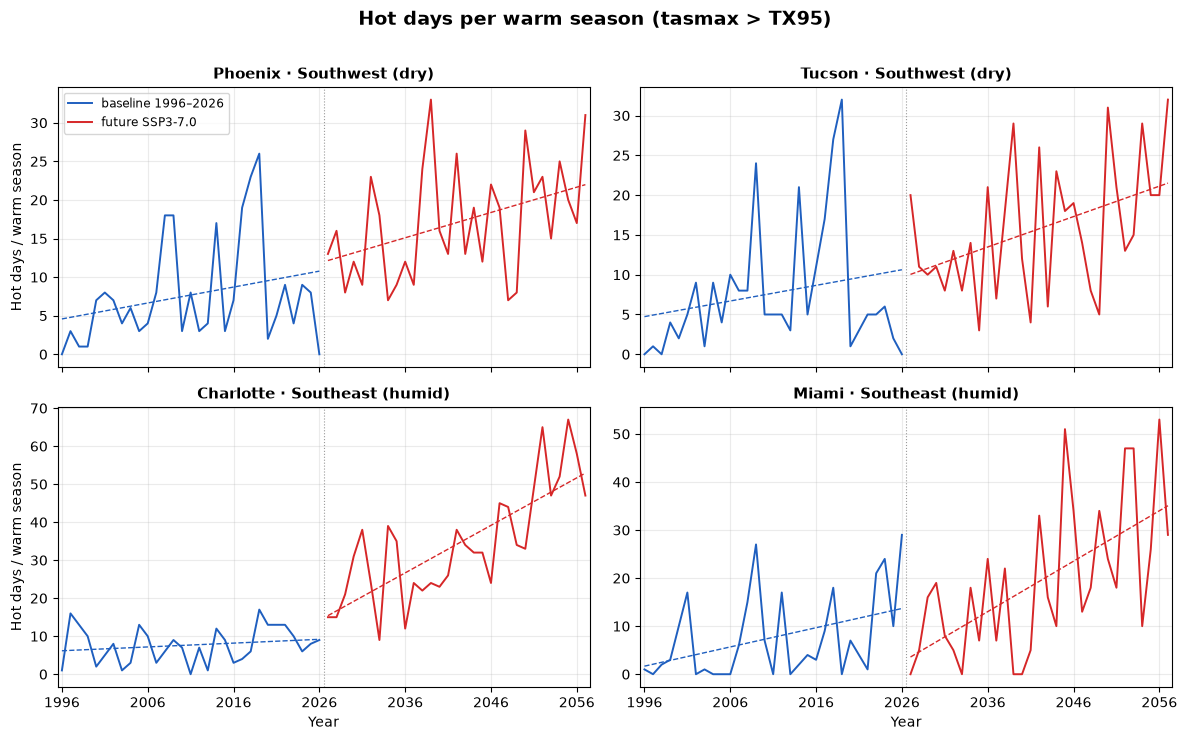

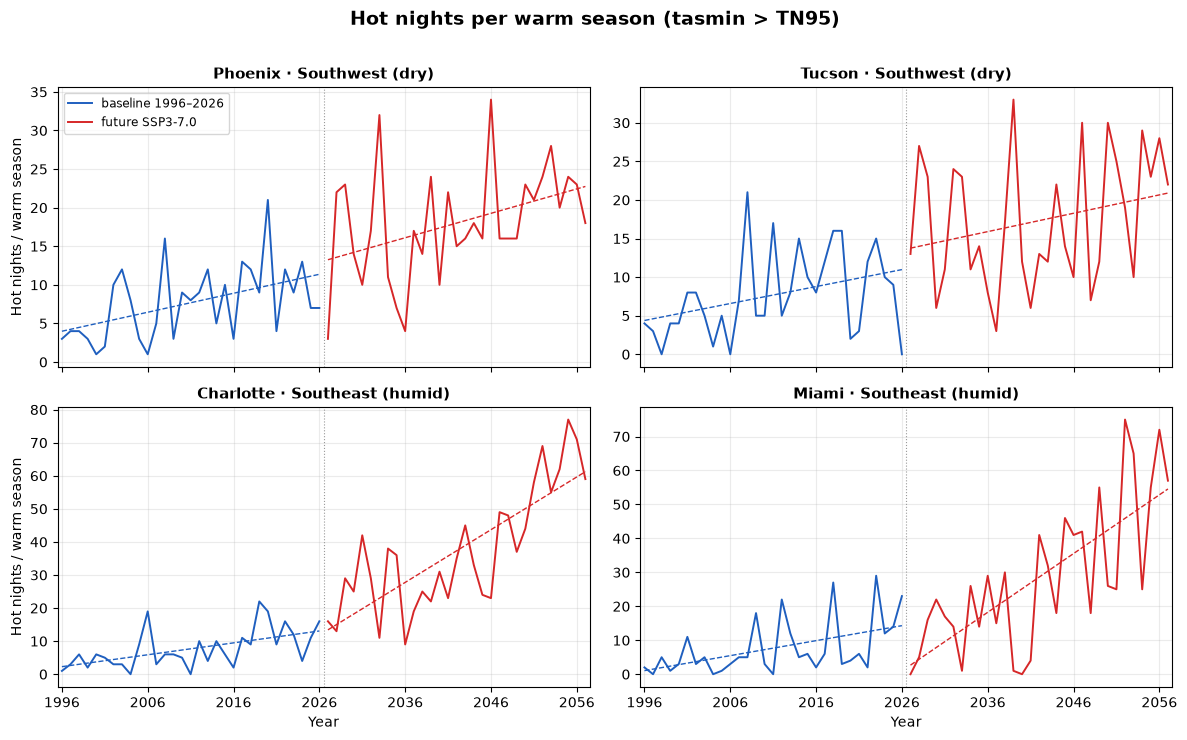

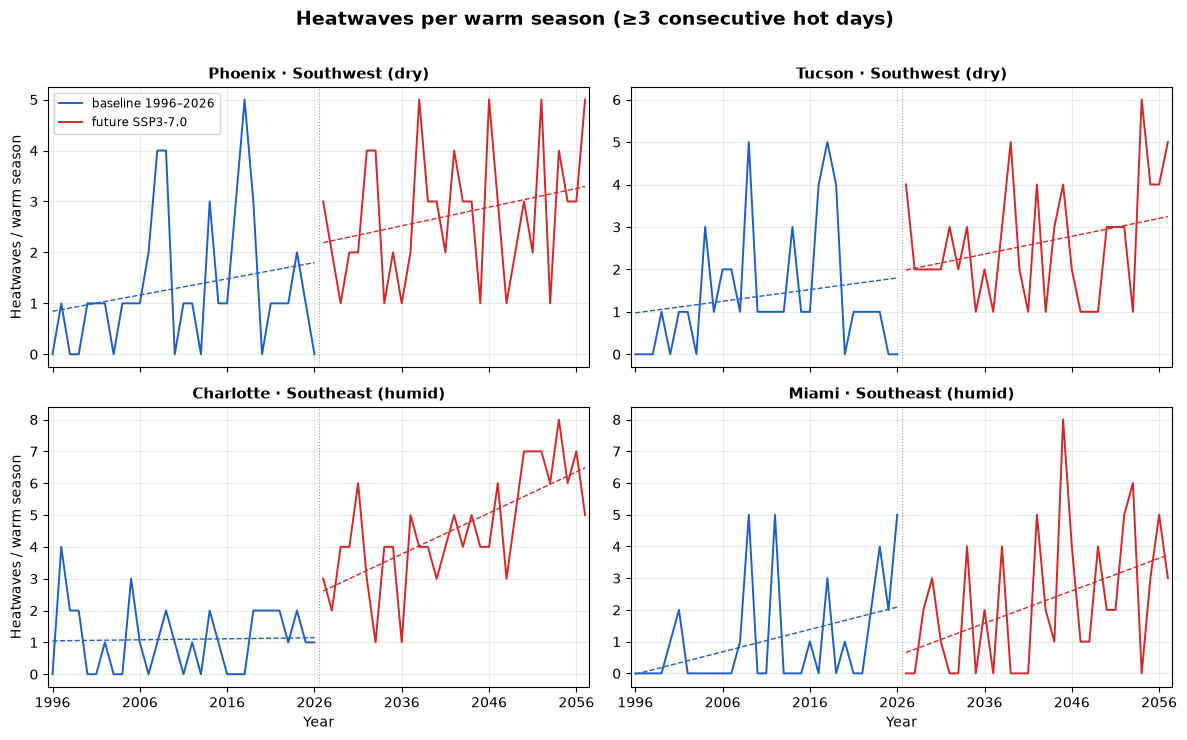

In [4]:
import matplotlib.pyplot as plt, numpy as np, os
REPO = "/pscratch/sd/s/sarya4/github/HeatWaveAnalysis"
FIG = f"{REPO}/figures"; os.makedirs(FIG, exist_ok=True)
m = pd.read_csv(f"{REPO}/data/metrics_by_year.csv")
REGION = {"Phoenix":"Southwest (dry)","Tucson":"Southwest (dry)",
          "Charlotte":"Southeast (humid)","Miami":"Southeast (humid)"}

def make(col, ylabel, title, fname):
    fig, ax = plt.subplots(2, 2, figsize=(12, 7.5), sharex=True)
    for a, city in zip(ax.ravel(), CITIES):
        d = m[m.city == city]; b = d[d.period=="baseline"]; f = d[d.period=="future"]
        a.plot(b.year, b[col], color="#1f5fbf", lw=1.4, label="baseline 1996–2026")
        a.plot(f.year, f[col], color="#d62728", lw=1.4, label="future SSP3-7.0")
        for seg, c in [(b,"#1f5fbf"), (f,"#d62728")]:
            s, i = np.polyfit(seg.year, seg[col], 1); a.plot(seg.year, s*seg.year+i, "--", color=c, lw=1)
        a.axvline(2026.5, color="0.6", lw=.8, ls=":"); a.grid(alpha=.25)
        a.set_xlim(1995.5, 2057.5)
        a.set_xticks(range(1996, 2058, 10))
        a.set_title(f"{city} · {REGION[city]}", fontsize=11, fontweight="bold")
    ax[0,0].legend(fontsize=8.5, loc="upper left")
    for a in ax[:,0]: a.set_ylabel(ylabel)
    for a in ax[1,:]: a.set_xlabel("Year")
    fig.suptitle(title, fontsize=14, fontweight="bold"); fig.tight_layout(rect=[0,0,1,.97])
    fig.savefig(f"{FIG}/{fname}", dpi=150, bbox_inches="tight"); print("saved", fname)

make("hot_days","Hot days / warm season","Hot days per warm season (tasmax > TX95)","fig_hot_days.png")
make("hot_nights","Hot nights / warm season","Hot nights per warm season (tasmin > TN95)","fig_hot_nights.png")
make("hw_events","Heatwaves / warm season","Heatwaves per warm season (≥3 consecutive hot days)","fig_heatwaves.png")